In [1]:
## What are embeddings

In [2]:
# Think of embeddings as a way to translate words into a language that computers understand - numbers.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Simplified 2D example ( real embeddings have hundreds of dimensions)
word_embeddings = {
    "cat" : [0.8, 0.6],
    "kitten" : [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

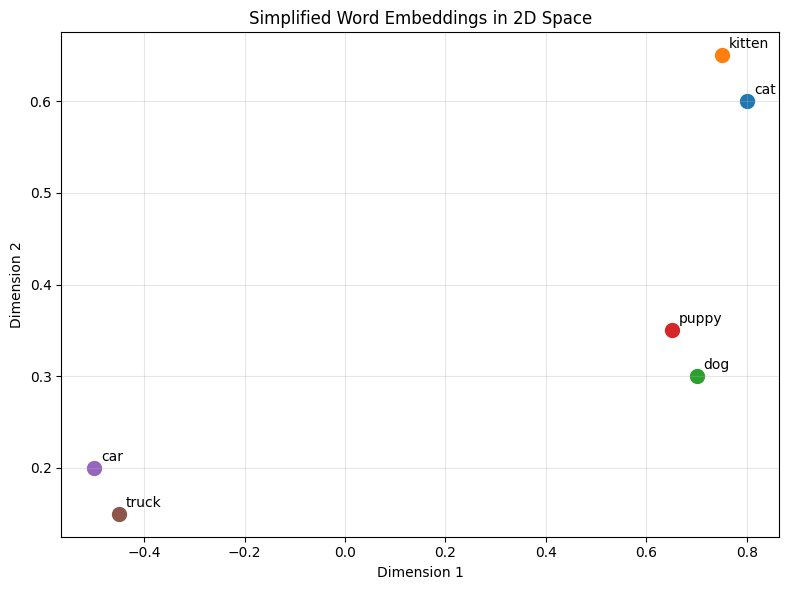

In [6]:
fig, ax = plt.subplots(figsize = (8,6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1] , s= 100)
    ax.annotate(word, (coords[0], coords[1]), xytext = (5,5), textcoords = 'offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

In [7]:
## Measuring similarity

In [8]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    -Result close to 1: Very similar
    -Result close to 0: Not related
    -Result close to -1: Opposite meanings
    """

    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)

    return dot_product / (norm_a * norm_b)

In [9]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector  = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity =  cosine_similarity(cat_vector, kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [10]:
cat_car_similarity = cosine_similarity(cat_vector, car_vector)
print(cat_car_similarity)

-0.43718588548916804


In [11]:
## Create your first embedding

In [13]:
### Hugging Face and OpenAI Models
from langchain_huggingface import HuggingFaceEmbeddings

## Initialize a simple Embedding model (no API key needed)
embeddings = HuggingFaceEmbeddings(model_name = "sentence-transformers/all-MiniLM-L6-v2")
embeddings

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2396.65it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [14]:
## create your first embeddings 
text = "Hello, I am learning about embedding"


embedding = embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding Length : {len(embedding)}")
print(embedding)

Text: Hello, I am learning about embedding
Embedding Length : 384
[-0.01254097931087017, -0.08428972214460373, -0.003735933220013976, -0.003694508457556367, 0.029054418206214905, 0.06126978248357773, 0.012031094171106815, 0.01772693544626236, 0.043435536324977875, -0.028131816536188126, 0.02011866867542267, 0.07650146633386612, 0.04530563950538635, 0.002255985513329506, -0.05790174752473831, 0.014729785732924938, 0.05218648910522461, 0.05656285583972931, -0.09237102419137955, -0.027782181277871132, -0.02874269150197506, -0.05491914972662926, 0.011186938732862473, -0.10679484903812408, 0.013341287150979042, -0.0188641007989645, -0.005179079249501228, 0.07339484989643097, 0.10817255079746246, -0.07271403819322586, 0.05805010348558426, -0.036489542573690414, -0.001090674544684589, 0.0577571876347065, -0.07553381472826004, 0.11141456663608551, 0.0254889614880085, -0.013313200324773788, -0.07460536062717438, -0.010939485393464565, 0.019129617139697075, 0.014313771389424801, -0.0235723573714

In [15]:
sentences = [
    "The cat sat on the mat",
    "A feline rested on the rug",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]


embedding_sentence = embeddings.embed_documents(sentences)

print(embedding_sentence[0])
print(embedding_sentence[1])

[0.1304018348455429, -0.011870143935084343, -0.028117045760154724, 0.05123864859342575, -0.055974461138248444, 0.03019157610833645, 0.0301612988114357, 0.02469835989177227, -0.018370550125837326, 0.058766789734363556, -0.02495318092405796, 0.06015429645776749, 0.039831750094890594, 0.03323053941130638, -0.06131138652563095, -0.049373120069503784, -0.054863523691892624, -0.04007606953382492, 0.05642912536859512, 0.03915657103061676, -0.03473709896206856, -0.013247691094875336, 0.031966231763362885, -0.06349925696849823, -0.06017860025167465, 0.0782344862818718, -0.028303857892751694, -0.047442834824323654, 0.040359266102313995, -0.006630869582295418, -0.06674093753099442, -0.004191359039396048, -0.02531164139509201, 0.053341638296842575, 0.017428111284971237, -0.09792359918355942, 0.006061280146241188, -0.06524161994457245, 0.04557257890701294, 0.023641828447580338, 0.0765848457813263, -0.010264387354254723, -0.004076810088008642, -0.062322843819856644, 0.033705271780490875, 0.018661133

In [16]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📊 Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📏 Embedding size: {info['size']} dimensions")
    print(f"  📝 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")


📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📏 Embedding size: 768 dimensions
  📝 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📏 Embedding size: 384 dimensions
  📝 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications

